In [1]:
import numpy as np
import json
import matplotlib.pyplot as plt
from pathlib import Path
import sys
from typing import Any

from project_root import PROJECT_ROOT, DATASETS_ROOT

In [2]:
ds_root = DATASETS_ROOT / "elephants/identity/dataset/certainty"
categories = [f.name for f in ds_root.glob("*")]
classes = [f.name for f in (ds_root / categories[0]).glob("*")]

image_count_totals = {
    category: len(list((ds_root / category).glob("**/*.jpg")))
    for category in categories
}

image_counts_by_class = {
    category: {
        cls: len(list((ds_root / category / cls).glob("**/*.jpg"))) for cls in classes
    }
    for category in categories
}

all_files = list(ds_root.glob("**/*.jpg"))
print(f"Total image count at {str(ds_root)}: {len(all_files)}")

Total image count at /home/dherrera/data/elephants/identity/dataset/certainty: 14569


<BarContainer object of 3 artists>

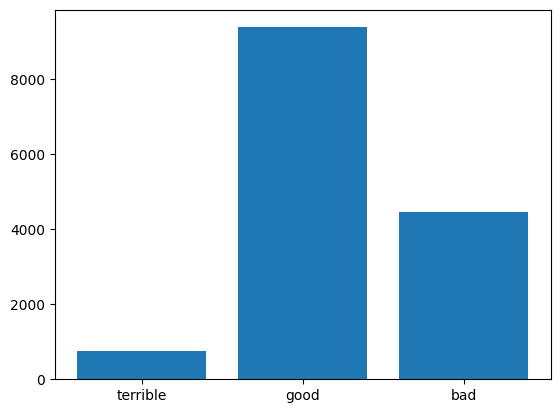

In [3]:
fig, axs = plt.subplots(1, 1)
ax = axs
ax.bar(image_count_totals.keys(), image_count_totals.values())

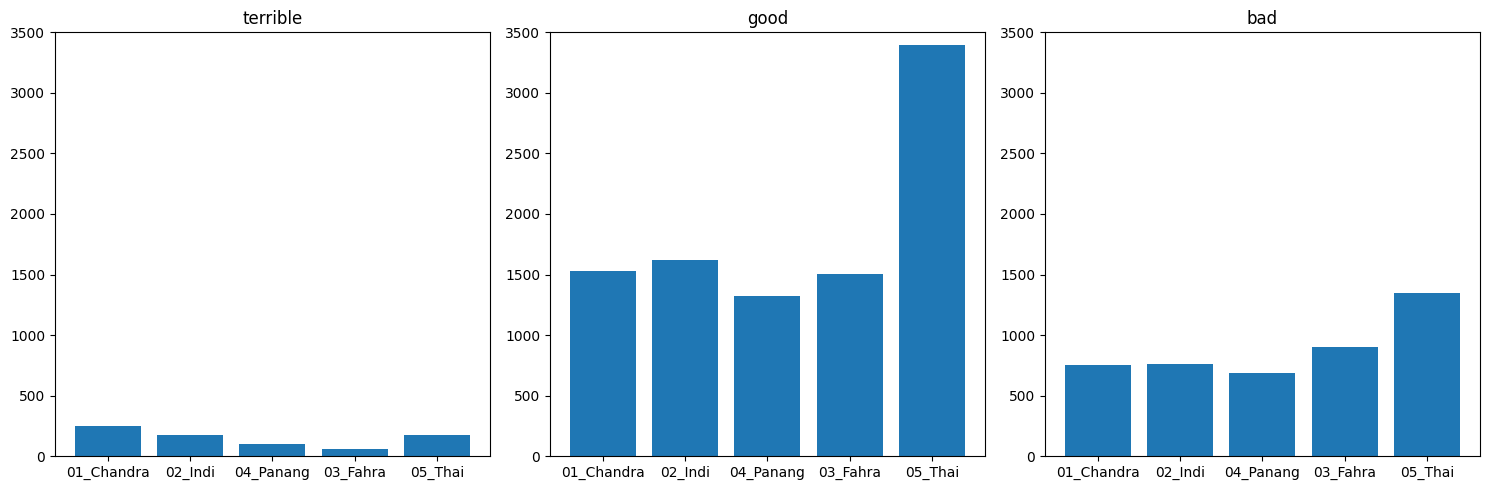

In [4]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
for category, ax in zip(categories, axs):
    image_counts = image_counts_by_class[category]
    ax.bar(image_counts.keys(), image_counts.values())
    ax.set_title(category)
    ax.set_ylim([0, 3500])
fig.tight_layout()